# Bench5: MgCl₂ injection into a calcite column (FEniCSx + GEMS)

Reproduces `Bench5-GEMS-FENICSX/bench5_calcite_dolomite_ADE_DG.ipynb` (paper
s10596-019-09919-3, §4.4, Fig. 6) with the four modules in `FEniCSx_GEMS_Beginner` (two folders up).
**All settings are in `case.yaml` in this folder**; this notebook explains them, runs
`python ../../coupling.py case.yaml` and plots the result. Nothing in the code cells needs
editing.

A MgCl₂ solution flows into a column of calcite-bearing water. Calcite dissolves, Mg meets
the released carbonate and **dolomite** precipitates in a band that moves downstream and
dissolves again behind the calcite front.

| Quantity | Benchmark | `case.yaml` |
|---|---|---|
| Column | 0.5 m | `transport.geometry.length`, 1000 cells |
| Porosity $\phi$ | 0.32, constant | `transport.material.phi`, feedback off |
| Pore velocity $v$ | 9.375×10⁻⁶ m/s | `darcy_flux` $q=\phi v = 3.0\times10^{-6}$ m/s |
| Dispersion $D$ | 2.01×10⁻⁸ m²/s | `De` $=\phi D = 6.432\times10^{-9}$ m²/s |
| Initial state | water in equilibrium with calcite, pH 9.9, calcite ≈ 0.2 mol/m³ | `chemistry.initial` |
| Inlet | Mg 1, Cl 2 mol/m³ water | `chemistry.inlet`, `boundary.left: dirichlet` |
| Outlet | advective outflow | `boundary.right: outflow` |
| Time | $\Delta t$ = 200 s, 105 steps to 21 000 s | `coupling.time` |

## 1  Transport: advection–dispersion

Every element except charge moves with the pore water. `transport.py` solves, for the
dissolved concentration $c_j$ in mol per m³ of pore water,

$$
\phi\,\frac{\partial c_j}{\partial t} + \frac{\partial}{\partial x}\!\Bigl(q\,c_j - D_e\,\frac{\partial c_j}{\partial x}\Bigr) = 0,
\qquad q = \phi v,\quad D_e = \phi D .
$$

Divided by $\phi$ this is the benchmark equation
$\partial_t c + v\,\partial_x c = D\,\partial_{xx} c$. Advection is switched on by
`material.darcy_flux` (0 or absent = pure diffusion, as in the cement example).

**Discretisation (DG0 finite volume, backward Euler).** One value per cell. Across each
internal face:

$$
F_{i+1/2} = \underbrace{q\,c_i}_{\text{upwind advection}}
\;-\; \underbrace{\frac{D_{e,i+1/2}}{\Delta x}(c_{i+1}-c_i)}_{\text{two-point dispersion}},
\qquad
\phi\,\frac{c_i^{n+1}-c_i^{n}}{\Delta t}\,\Delta x + F^{n+1}_{i+1/2} - F^{n+1}_{i-1/2} = 0 .
$$

The upwind flux takes the value from the upstream cell. With backward Euler this gives an
M-matrix: no oscillations and no negative concentrations.

**Boundaries.**

* Left, `dirichlet` (inflow): $F_{1/2} = q\,c_{\mathrm{in}} - \tfrac{2D_e}{\Delta x}(c_1 - c_{\mathrm{in}})$.
* Right, `outflow`: $F_{N+1/2} = q\,c_N$, zero dispersive gradient.

Both boundary fluxes are summed every step, so the mass-balance check in `coupling.py`
includes what enters and what leaves.

**Numerical dispersion.** First-order upwind adds about $v\Delta x/2$ and backward Euler about
$v^2\Delta t/2$ to $D$. With $\Delta t$ = 200 s the time part ($8.8\times10^{-9}$ m²/s) is the
same as in the benchmark notebook. The mesh part is kept small with 1000 cells
($2.3\times10^{-9}$ m²/s vs $D = 2.01\times10^{-8}$). A standalone check of this scheme gives a
Cl⁻ error vs the Ogata–Banks solution of 2.2 % (100 cells: 4.8 %; benchmark DG1: 2.0 %).

## 2  Chemistry

Each cell is in local equilibrium (GEMS, Gibbs energy minimisation at fixed $T$, $P$ and
element totals $\mathbf b = \mathbf b^{\mathrm{aq}} + \mathbf b^{\mathrm{sol}}$).
The GEMS files in `chemistry_data/` are the `ic-independent` set from the Bench5 folder, with
two points to know:

* **Independent components C, Ca, Cl, H, Mg, Zz (no O).** In this system every species obeys
  $2\,\mathrm O = 4\,\mathrm C + 2\,\mathrm{Ca} - \mathrm{Cl} + \mathrm H + 2\,\mathrm{Mg} - \mathrm{Zz}$,
  so an O row makes the stoichiometry matrix singular and GEMS fails (`E05IPM`). O is
  therefore not an element here; water appears as H₂ in the recipes.
* **Calcite lower limit removed.** The original files force `Cal ≥ 0.000204 mol`, which
  stops calcite from dissolving. In the copies here `dll`/`DLL` for `Cal` is 0 (the Bench5
  notebook does the same in memory with `setSpeciesLowerLimits`).

**Sample (`initial`).** The GEMS DBR state (1 L of water with calcite, pH 9.9, calcite
2.05×10⁻⁴ mol) scaled by 0.3190604 so that 1 dm³ of bulk holds 0.32 dm³ of pore water.
Calcite is then $6.5\times10^{-5}$ mol/dm³ bulk $=$ 0.204 mol per m³ of water, the 0.2 plateau of
Fig. 6.

**Boundary solution (`inlet`).** About 1 L of water with Mg and Cl chosen to give 1 and
2 mol/m³. C and Ca are set to $10^{-9}$ mol, the "empty" floor the Bench5 notebook uses to keep
GEMS well-posed when calcite is gone.

Charge $Z_z$ is not transported; every GEMS state is electroneutral.

## 3  Coupling: SNIA

Once per time step, in `coupling.py`:

1. **Transport** the dissolved elements (`aqueous`), minerals stay in place.
2. **Recombine** `total = immobile + aqueous`.
3. **React**: GEMS equilibrium in every cell.
4. **Check**: inventory change = inflow − outflow, otherwise the run stops.

Porosity and $D_e$ stay constant (`update_porosity: false`), as in the benchmark.

## 4  Settings

The file that is run:

In [7]:
print(open("case.yaml", encoding="utf-8").read())

# Bench5 / Benchmark 4: MgCl2 injection into a calcite column (paper s10596-019-09919-3, 4.4, Fig. 6),
# reproduced with the four modules two folders up (FEniCSx_GEMS_Beginner).
# Run from this folder:  python ../../coupling.py case.yaml   (or Run.cmd, or the notebook)
#
# 0.5 m column, porosity 0.32, pore velocity 9.375e-6 m/s, D = 2.01e-8 m2/s,
# MgCl2 (Mg 1, Cl 2 mol/m3 water) enters on the left, advective outflow on the right,
# calcite dissolves, dolomite forms in a moving band. dt = 200 s, end = 21000 s.

# 1. chemistry.py: GEMS project, chemical conditions, and recipes.
chemistry:
  project: chemistry_data/ic-independent-dat.lst   # C-Ca-Cl-H-Mg-Zz basis, calcite lower limit removed
  temperature: 298.15                  # K
  pressure: 100000                     # Pa
  aqueous_phase: aq_gen
  solid_phases: [Calcite, Dolomite-dis]

  # No Gibbs energy adjustments in this benchmark.
  gibbs: {}

  # Sample: element amounts in mol per 1 dm3 of BULK sample (pore water + solids).
  

## 5  Run

Same as double-clicking `Run.cmd`: 105 steps × 1000 cells.

In [8]:
import sys
!{sys.executable} ../../coupling.py case.yaml

[2026-09-24 15:48:10.830] [gems3k] [info] Home directory is /home/xi_b
step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=1.355e-17 mol/m3, water mismatch=0.00%
step=21, time=4200 s, balance=4.479e-10 mol/m2, chemistry=2.373e-09 mol/m3, water mismatch=0.00%
step=42, time=8400 s, balance=2.056e-09 mol/m2, chemistry=1.350e-10 mol/m3, water mismatch=0.00%
step=63, time=12600 s, balance=3.275e-09 mol/m2, chemistry=2.878e-09 mol/m3, water mismatch=0.00%
step=84, time=16800 s, balance=4.071e-09 mol/m2, chemistry=2.494e-09 mol/m3, water mismatch=0.00%
step=105, time=21000 s, balance=5.183e-09 mol/m2, chemistry=2.011e-09 mol/m3, water mismatch=0.00%
Saved: /mnt/c/Users/xi_b/3D Objects/suduko/GEMS-FENICSX/FEniCSx_GEMS_Beginner/exsample/demo_bench5/results


## 6  Results

`summary.txt` and the overview plot written by `output.py`.

COMPLETED
Mode: coupled
Cells/states: 1000; reference length: 0.5 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 21000.0 s; steps: 105
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 5.183225e-09 mol/m2
Maximum chemical element reconstruction error: 4.746724e-09 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.000276%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 0.32 to 0.32
Final De range: 6.432e-09 to 6.432e-09 m2/s
Porosity feedback: False
Diffusivity feedback: False
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



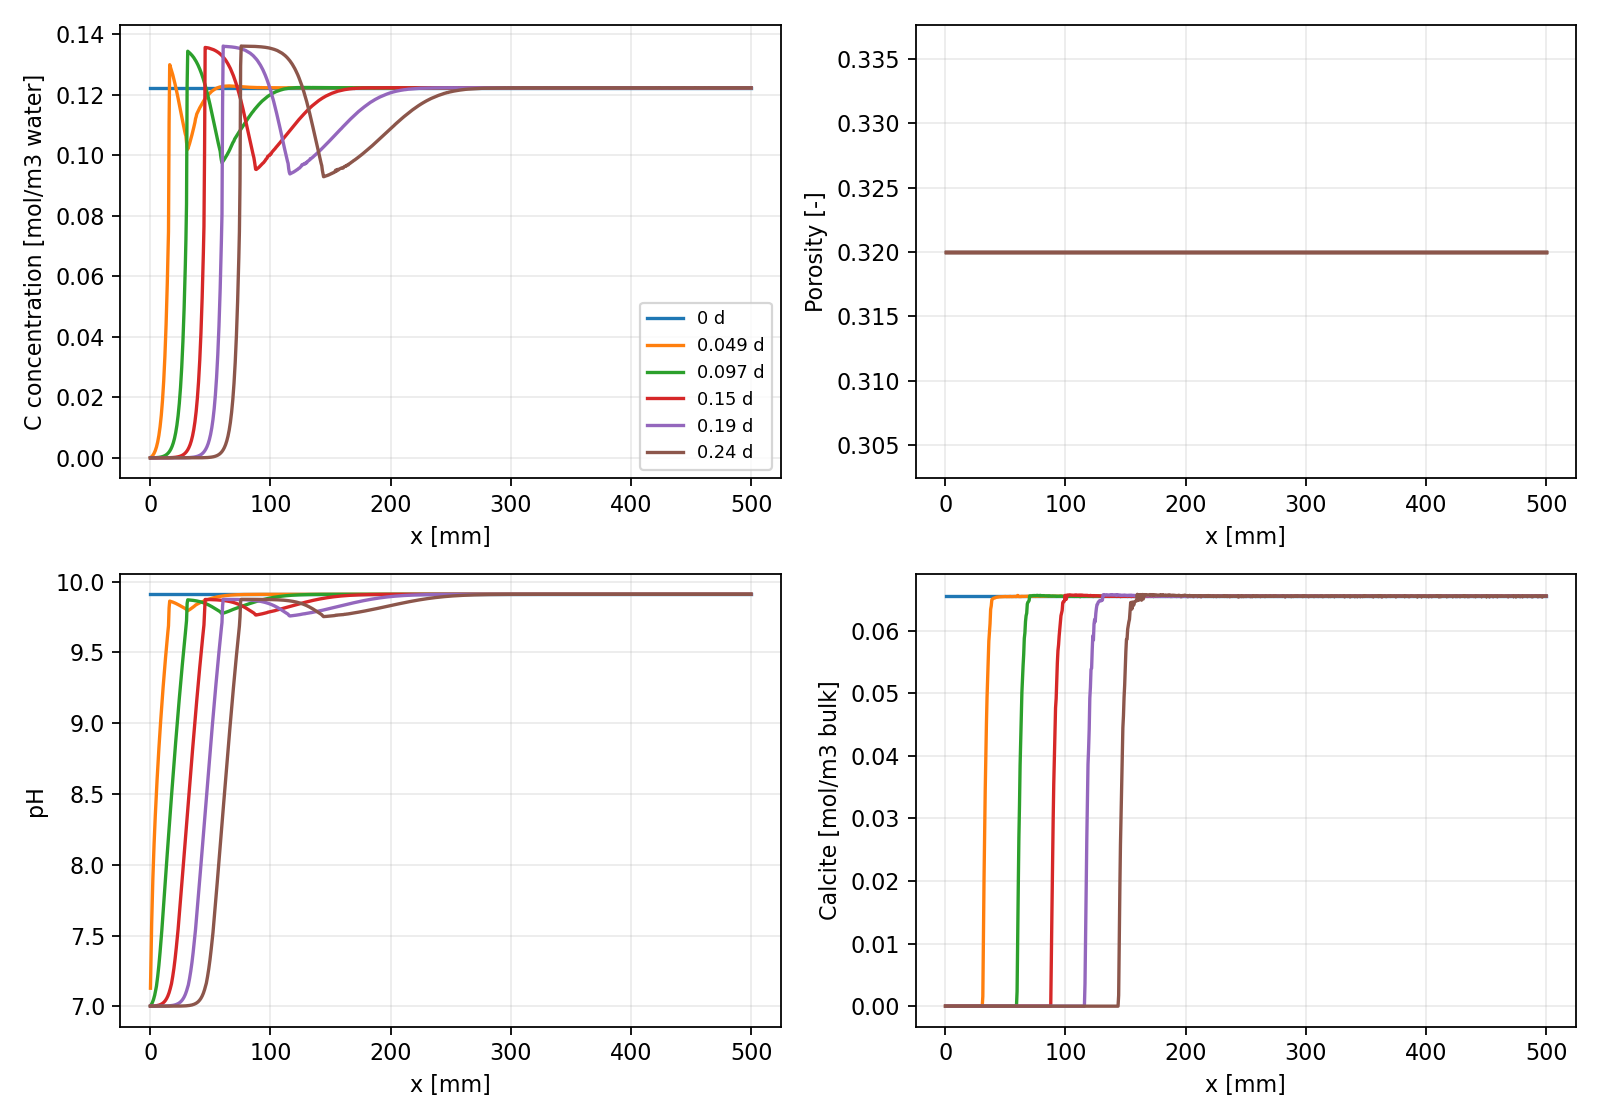

In [9]:
import yaml
from pathlib import Path
from IPython.display import Image, display

case = yaml.safe_load(open("case.yaml"))
results = Path(case["output"]["folder"])
print((results / "summary.txt").read_text())
display(Image(filename=str(results / "profiles.png")))

## 7  Comparison with the paper, Fig. 6 (t = 21 000 s)

Left: this model, drawn in the layout of Fig. 6. Right: the published figure.
Concentrations are in mol per m³ of water; minerals are converted from mol/m³ bulk to mol
per m³ of water (÷ $\phi$), as in the paper. This model reports **element** concentrations;
Ca and Mg are dominated by Ca²⁺ and Mg²⁺ here, Cl is exactly Cl⁻.

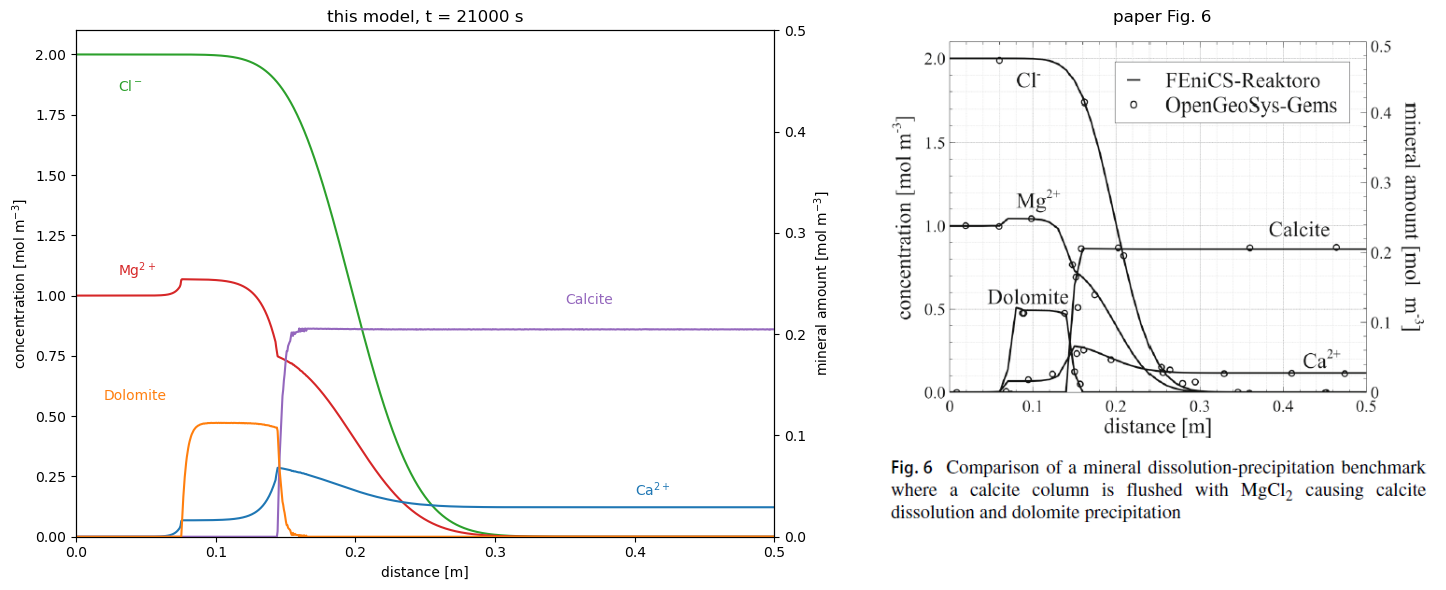

calcite plateau [mol/m3 water] : 0.2057
dolomite peak   [mol/m3 water] : 0.1125
dolomite band (> 0.01)         : 0.076 - 0.151 m


In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

phi = case["transport"]["material"]["phi"]
p = pd.read_csv(results / "profiles.csv")
t_end = p["time_s"].max()
s = p[p["time_s"] == t_end].sort_values("x_m")

fig, (ax1, axi) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.1, 1]})
ax2 = ax1.twinx()
ax1.plot(s["x_m"], s["Cl_c_mol_m3_water"], color="tab:green")
ax1.plot(s["x_m"], s["Mg_c_mol_m3_water"], color="tab:red")
ax1.plot(s["x_m"], s["Ca_c_mol_m3_water"], color="tab:blue")
ax2.plot(s["x_m"], s["Calcite_mol_m3_bulk"] / phi, color="tab:purple")
ax2.plot(s["x_m"], s["Dolomite-dis_mol_m3_bulk"] / phi, color="tab:orange")
ax1.set(xlim=(0, 0.5), ylim=(0, 2.1), xlabel="distance [m]", ylabel="concentration [mol m$^{-3}$]")
ax2.set(ylim=(0, 0.5), ylabel="mineral amount [mol m$^{-3}$]")
ax1.text(0.03, 1.85, "Cl$^-$", color="tab:green")
ax1.text(0.03, 1.08, "Mg$^{2+}$", color="tab:red")
ax1.text(0.40, 0.17, "Ca$^{2+}$", color="tab:blue")
ax2.text(0.35, 0.23, "Calcite", color="tab:purple")
ax2.text(0.02, 0.135, "Dolomite", color="tab:orange")
ax1.set_title(f"this model, t = {t_end:.0f} s")
axi.imshow(plt.imread("reference/paper_fig6_bench5.png")); axi.axis("off"); axi.set_title("paper Fig. 6")
plt.tight_layout(); plt.show()

x = s["x_m"].to_numpy()
dol = s["Dolomite-dis_mol_m3_bulk"].to_numpy() / phi
band = x[dol > 0.01]
print(f"calcite plateau [mol/m3 water] : {(s['Calcite_mol_m3_bulk'] / phi).max():.4f}")
print(f"dolomite peak   [mol/m3 water] : {dol.max():.4f}")
print("dolomite band (> 0.01)         : " + (f"{band.min():.3f} - {band.max():.3f} m" if band.size else "none"))

### 7.1  Evolution

Saved profiles every `output.every` steps.

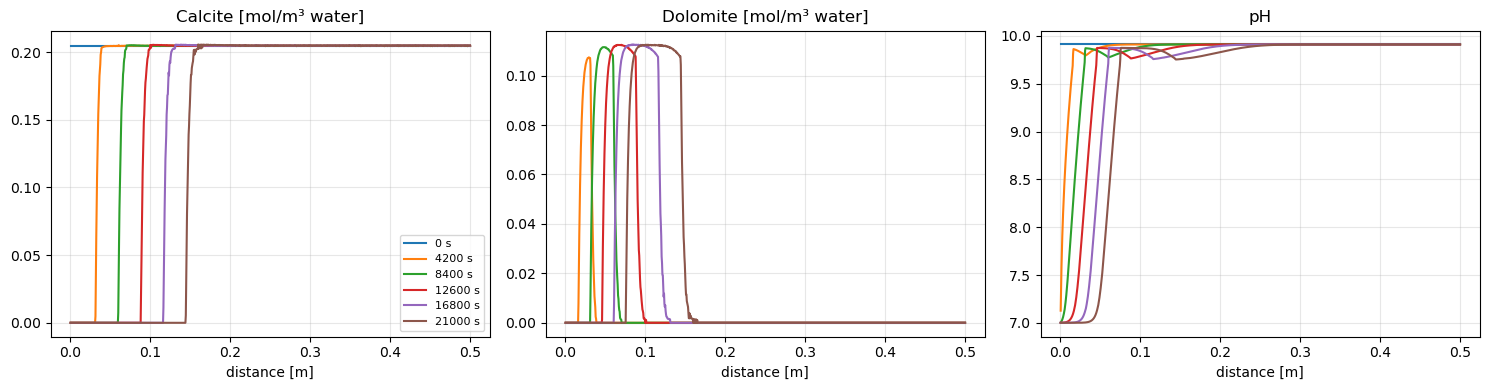

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, (t, g) in enumerate(p.groupby("time_s")):
    g = g.sort_values("x_m")
    axes[0].plot(g["x_m"], g["Calcite_mol_m3_bulk"] / phi, color=f"C{k}", label=f"{t:.0f} s")
    axes[1].plot(g["x_m"], g["Dolomite-dis_mol_m3_bulk"] / phi, color=f"C{k}")
    axes[2].plot(g["x_m"], g["pH"], color=f"C{k}")
for ax, title in zip(axes, ["Calcite [mol/m³ water]", "Dolomite [mol/m³ water]", "pH"]):
    ax.set_title(title); ax.set_xlabel("distance [m]"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8  Differences to the Bench5 ADE_DG notebook

| | Bench5 ADE_DG | This model |
|---|---|---|
| Transport | DG1 interior penalty, 100 cells, species transported | DG0 upwind finite volume, 1000 cells, **elements** transported |
| Chemistry points | one GEMS state per DG1 dof (600), warm start | one per cell (1000), cold start + scaled retries |
| Inlet | species concentrations fixed, other solutes 0 | GEMS-equilibrated MgCl₂ recipe, C and Ca at 1e-9 mol |
| Element floor | totals floored at 1e-9 mol every step | none; inlet trace C/Ca plays that role |
| Calcite lower limit | cleared in memory | cleared in the copied GEMS files |
| Settings | constants in the notebook | `case.yaml` |

Chemical database, basis, porosity, velocity, dispersion, $\Delta t$ and end time are the same.
Expect small differences at the fronts from the transport discretisation.